O Naive Bayes é um algoritmo de aprendizado de máquina (Machine Learning) rápido e probabilístico usado para tarefas de classificação. Ele é baseado no Teorema de Bayes e calcula a chance de um dado pertencer a uma categoria específica. É chamado de "ingênuo" porque assume que todas as características analisadas são independentes entre si.

VC DIVIDE A BASE DE DADOS EM DUAS TABELAS: 1- VARIAVEIS QUE NÃO SEJAM ID_CLIENTE(CHAVES PRIMARIAS) NEM VARIAVEL PARA QUE SE
POSSA CLASSIFICAR A UMA DETERMINADA CATEGORIA. NO CASO DA TABELA ABAIXO É C#DEFAULT(0 OU 1 - SE PAGOU OU NÃO O EMPRESTIMO).
2- SEGUNDA TABELA, SERÁ A VARIAVEL DE CLASSIFICAÇÃO, NO CASO A C#DEFAULT

In [1]:
import random
import numpy as np
import pandas as pd

random.seed(42)

dataset = pd.read_csv('credit_data.csv')

# display(dataset.shape)
display(dataset.head())

dataset.dropna(inplace=True) #Modificar o DataFrame original
#-> apaga as linhas em branco do dataframe original, sem precisar criar uma variavel tipo: novo_df= dataset.dropna()
#display(dataset.info())

print('valores da tabela 1  - variaveis comuns')
x = dataset.iloc[:, 1:4].values
#print(x)
print('valores da tabela 2  - variavel de classificação') # sim ou não / 0 ou 1
y = dataset.iloc[:, 4].values
#print(y)

from sklearn.model_selection import train_test_split #fazer a estratificação
#CRIAÇÃO DE TABELAS PARA MACHINE LEARNING -BASE DE TESTE E TREINAMENTO
#0.2 representa os 20% para teste, estratificada de y que é a categoria de classificação
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x, y, test_size= 0.2, stratify= y, random_state=42)

print(x_teste.shape), print(x_treinamento.shape)
print(y_teste.shape), print(y_treinamento.shape)

#VERIFICANDO AS PORCENTAGENS DA POPULAÇÃO
print(np.unique(y, return_counts=True)) # retorna 0 que pagaram emprestimo = 1714, 1 que não pagaram =283

pagaram = 1714/len(dataset)
nao_pagaram = 283/len(dataset)
print(f'pagaram: {pagaram:.0%}, não pagaram: {nao_pagaram:.0%}')

#VERIFICANDO SE AS PORCENTAGENS DA AMOSTRA ESTÃO IGUAIS DA POPULAÇÃO
print(np.unique(y_treinamento, return_counts= True))
pagaram1 = 1371/len(y_treinamento)
nao_pagaram1 = 226/len(y_treinamento)
print(f'pagaram: {pagaram1:.0%}, não pagaram: {nao_pagaram1:.0%}')


,i#clientid,income,age,loan,c#default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


valores da tabela 1  - variaveis comuns
valores da tabela 2  - variavel de classificação
(400, 3)
(1597, 3)
(400,)
(1597,)
(array([0, 1]), array([1714,  283]))
pagaram: 86%, não pagaram: 14%
(array([0, 1]), array([1371,  226]))
pagaram: 86%, não pagaram: 14%


In [2]:
from sklearn.naive_bayes import GaussianNB
#cria-se o modelo de treinamento
modelo = GaussianNB()
modelo.fit(x_treinamento, y_treinamento) #gerar a tabela de probabilidade

#depois faz as previsões com teste

previsoes = modelo.predict(x_teste) #valor previsto pelo seu modelo
print(f'previsões: {previsoes}')

print('y_teste')
print(y_teste) #valor real


previsões: [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
y_teste
[0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 

In [3]:
from sklearn.metrics import accuracy_score
# O accuracy_score (ou escore de acurácia) é uma métrica de Machine Learning 
# que mede a porcentagem de acertos do seu modelo em relação ao total de previsões.
# Ele é frequentemente usado em problemas de classificação (ex: prever se um e-mail é spam ou não).
#acurrancy = n. de previsoes corretas / previsoes totais
# A acurácia é a métrica mais direta e simples de entender.
# Ela responde à pergunta: "De todas as previsões que o modelo fez, qual porcentagem ele acertou?"

print(accuracy_score(y_teste, previsoes))




0.9275


In [4]:
# Uma matriz de confusão (confusion matrix) é uma tabela que avalia o desempenho de um modelo de classificação, 
# mostrando os erros e acertos em comparação com os valores reais.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_teste, previsoes)
print(cm)

[[339   4]
 [ 25  32]]


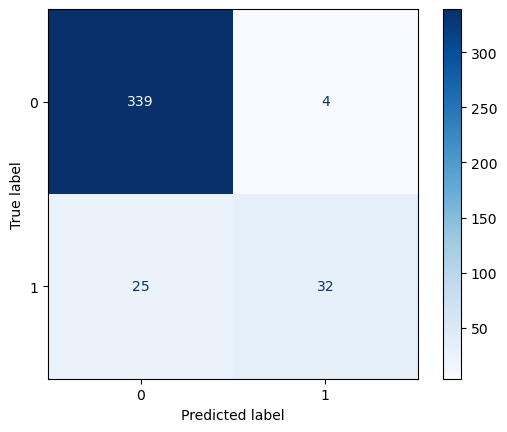

In [5]:
# O sns.heatmap transforma esses números em um gráfico colorido (mapa de calor), facilitando a leitura rápida: 
#   as cores mais escuras geralmente indicam onde estão a maioria dos seus dados.
import matplotlib.pyplot as plt
import seaborn as sns
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) #no lugar de zero pode ser 'sim' ou 'não, depende da tabela
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [6]:
#O resultado da acurácia é a soma dos (340-dos que pagam(0,0) + 37-dos que não pagam(1,1))/dividido(334+9+26+31)-soma todos os valores do quadrante
porcentagem = (340 + 37)/(340+37+20+3) 
print(porcentagem)

0.9425


In [7]:
#PERCENTUAL DE ACERTO PARA PESSOAS QUE PAGAM O EMPRESTIMO:

pagam = 340/ (340+3) #total de pagantes (0,0) / total de pagantes (0,0) + (0,1) -todos de cima
print(pagam*100)

99.12536443148689


In [8]:
#PERCENTUAL DE ACERTO PARA PESSOAS QUE NÃO PAGAM O EMPRESTIMO:

nao_pagam = 37 / (20+37) #total de não pagantes (1,1) / divididos de todos de baixo
print(nao_pagam * 100)

64.91228070175438


In [9]:
estimativa_perda_do_banco_por_cliente = 5000
cliente_nao_pagador = 1000
percentual_de_emprestimo_cliente = (1000 * 35 )/ 100 #35 é a diferenca entre 64.91 - 100, esses 35% é para quem o banco emprestaria
print(percentual_de_emprestimo_cliente) #emprestaria para 350 pessoas
perda = estimativa_perda_do_banco_por_cliente *percentual_de_emprestimo_cliente
print(f'Perda em dinheiro do banco: {perda:,.2f}')


350.0
Perda em dinheiro do banco: 1,750,000.00


A subamostragem (undersampling) é uma técnica para balancear dados. 
Ela reduz a quantidade de dados da classe majoritária (mais abundante). 
Isso evita que o modelo de Machine Learning fique tendencioso.
A subamostragem (amplamente conhecida pelo termo em inglês undersampling) é uma técnica usada em Machine Learning para lidar com o problema de classes desbalanceadas.

Esse desbalanceamento ocorre quando o seu conjunto de dados tem muito mais exemplos de uma classe (a classe majoritária) do que de outra (a classe minoritária). Se você treinar um modelo com esses dados brutos, ele provavelmente vai aprender a chutar sempre a classe majoritária e vai ignorar a minoritária, o que é um problemão.

A ideia do undersampling é muito simples: você reduz a quantidade de exemplos da classe majoritária até que ela fique em um nível comparável ao da classe minoritária.

Como funciona na prática?
Imagine que você está construindo um modelo para detectar fraudes em cartões de crédito:

Classe A (Transações Legítimas): 99.000 exemplos (Majoritária)

Classe B (Transações Fraudulentas): 1.000 exemplos (Minoritária)

Se você aplicar o undersampling mais básico (chamado de Random Undersampling), o algoritmo vai selecionar aleatoriamente apenas 1.000 exemplos das transações legítimas e descartar os outros 98.000. No final, seu modelo será treinado com um dataset perfeitamente equilibrado de 2.000 exemplos (1.000 legítimos e 1.000 fraudes).

Prós e Contras do Undersampling
Como quase tudo em ciência de dados, essa técnica envolve um trade-off (uma troca):

Vantagens:

Velocidade de Treinamento: Como você está reduzindo drasticamente o tamanho do dataset, o modelo treina muito mais rápido e consome muito menos memória.

Melhora a sensibilidade: O modelo passa a dar importância para a classe minoritária, melhorando métricas como o Recall (sua capacidade de detectar fraudes, por exemplo).

Desvantagens (O grande perigo):

Perda de Informação: Ao descartar a maior parte da classe majoritária, você pode estar jogando fora dados valiosos, padrões importantes e nuances que ajudariam o modelo a generalizar melhor no mundo real.

Técnicas Avançadas de Undersampling
Para não depender apenas da sorte escolhendo dados aleatórios, existem abordagens estatísticas mais inteligentes:

Tomek Links: Identifica pares de pontos de classes opostas que estão muito próximos um do outro (limítrofes). O algoritmo remove o elemento da classe majoritária desse par, tornando a linha de separação entre as classes muito mais clara para o modelo.

Cluster Centroids: Usa o algoritmo K-Means para agrupar a classe majoritária em "clusters" (grupos) e substitui o monte de dados originais apenas pelos centros desses grupos. Assim, você mantém a estrutura dos dados, mas com muito menos pontos.

NearMiss: Seleciona os exemplos da classe majoritária com base na distância em relação aos exemplos da classe minoritária (existem variações que pegam os mais próximos ou os mais distantes).

Regra de ouro: Geralmente, o undersampling é preferido quando você tem um volume de dados absurdamente gigante (onde perder dados não vai deixar seu dataset "pobre"). Se você tem poucos dados no total, o caminho inverso — o oversampling (criar dados sintéticos para a classe minoritária, como o SMOTE) — costuma ser mais seguro.

In [10]:
from imblearn.under_sampling import TomekLinks

tl= TomekLinks(sampling_strategy='majority')
x_under, y_under= tl.fit_resample(x, y) #x, y - bases originais
id_under = tl.sample_indices_
print(x_under.shape)
print(y_under.shape)
print(id_under)

(1897, 3)
(1897,)
[   0    1    2 ... 1994 1995 1996]


In [11]:
print(np.unique(y, return_counts=True))
print(np.unique(y_under, return_counts=True))

(array([0, 1]), array([1714,  283]))
(array([0, 1]), array([1614,  283]))


In [12]:
x_treinamento_u, x_teste_u, y_treinamento_u, y_teste_u = train_test_split(x_under, y_under, test_size=0.2, stratify=y_under)

print(x_treinamento_u.shape)
print(x_teste_u.shape)

(1517, 3)
(380, 3)


In [13]:
modelo_u = GaussianNB()
modelo_u.fit(x_treinamento_u, y_treinamento_u)
previsoes_u = modelo_u.predict(x_teste_u)
print(accuracy_score(previsoes_u, y_teste_u))

0.9131578947368421


In [14]:
cm_u = confusion_matrix(previsoes_u, y_teste_u)
print(cm_u)

[[314  24]
 [  9  33]]


In [15]:
#PERCENTUAL DE ACERTO PARA PESSOAS QUE PAGAM O EMPRESTIMO:

pagam2 = 316/ (316+22) #total de pagantes (0,0) / total de pagantes (0,0) + (0,1) -todos de cima
print(pagam2*100)

93.49112426035504


In [16]:
#PERCENTUAL DE ACERTO PARA PESSOAS QUE NÃO PAGAM O EMPRESTIMO:

nao_pagam1 = 35/ (7+35) #total de pagantes (0,0) / total de pagantes (0,0) + (0,1) -todos de cima
print(nao_pagam*100)

64.91228070175438
